# cenario B antena e posicao

=== Cenário B - Otimização de Posições + Ângulos ===
Área de decisão: 100x100 metros
Posição do Jammer: x=50.00, y=100.00

Geração 0: Fitness Máximo = 10743.099864, Médio = 314.318237
Geração 50: Fitness Máximo = 2770146.802123, Médio = 2258203.579257
Geração 100: Fitness Máximo = 3559208.313041, Médio = 3045160.429920
Geração 150: Fitness Máximo = 4196741.862060, Médio = 3545144.102898
Geração 200: Fitness Máximo = 4303653.277018, Médio = 3727862.991688
Geração 250: Fitness Máximo = 4305338.153370, Médio = 3698783.770997
Geração 300: Fitness Máximo = 4324405.178304, Médio = 3669667.495367
Geração 350: Fitness Máximo = 4329622.040735, Médio = 3650622.141289
Geração 400: Fitness Máximo = 4332854.489753, Médio = 3698199.864215
Geração 450: Fitness Máximo = 4333280.674359, Médio = 3729871.168340
Geração 499: Fitness Máximo = 4333416.260529, Médio = 3679176.254671
=== Resultados da Otimização ===
Posições e ângulos ótimos dos UAVs:
  UAV 0: x=14.47, y=13.27, angle=84.31°
  UAV 1: x=34.28, 

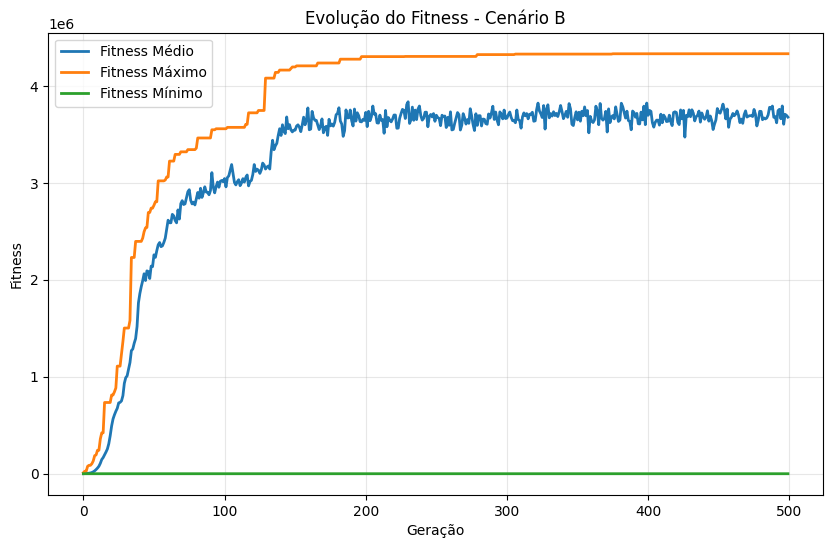

Gráfico salvo como 'fitness_evolution_scenario_b.png'


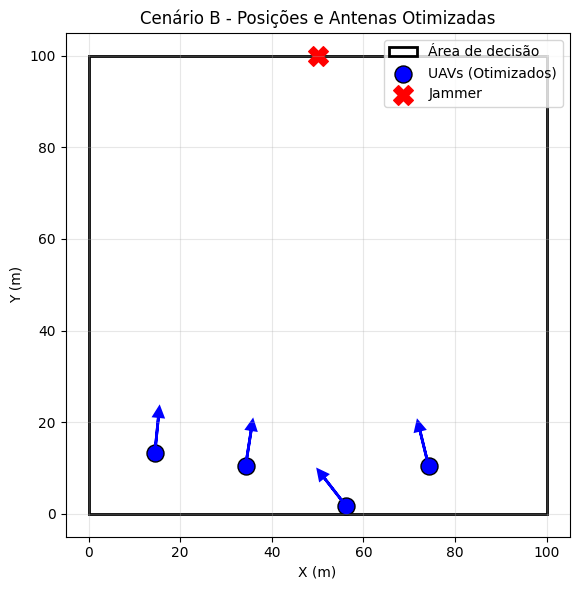

In [4]:
import random
import numpy as np
import math
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
from functools import partial
import networkx as nx
from link_capacity import calcular_capacidade_link, interference_from_jammer
from antenna_null import realistic_antenna_gain
import copy

NUM_UAVS = 4
lambda_0 = 0.125
P_INTERFERENCE_DBM = 100
P_NOISE_DBM = -100
BANDWIDTH = 20e6
TRANSMIT_POWER_DBM = 20
MINDIST = 20

# Definir os tipos de indivíduos e fitness
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# CENÁRIO B - Otimização de Posições + Ângulos das Antenas

def create_individual_scenario_b(num_uavs, area_size=100):
    """
    Cria um indivíduo para o Cenário B com posições (x,y) e ângulos das antenas.
    Cada UAV tem: [x, y, angle]
    """
    individual = []
    attempts = 0
    max_attempts = 1000
    
    while len(individual) < num_uavs * 3 and attempts < max_attempts:
        x = random.uniform(0, area_size)
        y = random.uniform(0, area_size)
        angle = random.uniform(0, 360)
        
        # Verificar se a nova posição está longe o suficiente das anteriores
        valid_position = True
        current_positions = []
        for i in range(0, len(individual), 3):
            current_positions.append([individual[i], individual[i+1]])
        
        for pos in current_positions:
            distance = np.linalg.norm(np.array([x, y]) - np.array(pos))
            if distance < MINDIST:
                valid_position = False
                break
        
        if valid_position:
            individual.extend([x, y, angle])
        
        attempts += 1
    
    # Se não conseguir gerar todas as posições válidas, aceitar assim mesmo
    while len(individual) < num_uavs * 3:
        x = random.uniform(0, area_size)
        y = random.uniform(0, area_size)
        angle = random.uniform(0, 360)
        individual.extend([x, y, angle])
    
    return creator.Individual(individual)

def extract_positions_and_angles(individual, num_uavs):
    """
    Extrai posições e ângulos do indivíduo.
    Returns: (uav_positions, angles)
    """
    uav_positions = []
    angles = []
    
    for i in range(num_uavs):
        idx = i * 3  # Cada UAV tem 3 valores: x, y, angle
        x = individual[idx]
        y = individual[idx + 1]
        angle = individual[idx + 2]
        
        uav_positions.append(np.array([x, y]))
        angles.append(angle)
    
    return uav_positions, angles

def plot_scenario_b(best_solution, jammer_position, num_uavs, filename="scenario_b.png"):
    """
    Plota o cenário B com posições e ângulos otimizados.
    """
    uav_positions, angles = extract_positions_and_angles(best_solution, num_uavs)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plotar área de decisão como quadrado preto
    square_size = 100
    square_x = 0
    square_y = 0
    square = plt.Rectangle((square_x, square_y), square_size, square_size, 
                          fill=False, edgecolor='black', linewidth=2, linestyle='-',
                          label='Área de decisão')
    ax.add_patch(square)
    
    # Plotar UAVs como círculos
    for i, pos in enumerate(uav_positions):
        if i == 0:
            ax.scatter(pos[0], pos[1], c='blue', s=150, marker='o', 
                      edgecolors='black', label='UAVs (Otimizados)')
        else:
            ax.scatter(pos[0], pos[1], c='blue', s=150, marker='o', edgecolors='black')
        
        # Seta indicando direção da antena
        angle_rad = np.radians(angles[i])
        arrow_length = 8
        end_x = pos[0] + arrow_length * np.cos(angle_rad)
        end_y = pos[1] + arrow_length * np.sin(angle_rad)
        
        ax.arrow(pos[0], pos[1], end_x - pos[0], end_y - pos[1],
                head_width=2, head_length=2, fc='blue', ec='blue', linewidth=2)
    
    # Plotar jammer como cruz vermelha
    ax.scatter(jammer_position[0], jammer_position[1], c='red', s=200, 
              marker='X', label='Jammer')
    
    # Configurar plot
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Cenário B - Posições e Antenas Otimizadas')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def print_communication_values_scenario_b(individual, num_uavs, jammer_position):
    """
    Calcula e imprime os valores de comunicação para o cenário B.
    """
    uav_positions, angles = extract_positions_and_angles(individual, num_uavs)
    alignments = [1.0] * num_uavs
    
    comm_matrix, interference_matrix = calculate_communication_capacity(
        angles, alignments, uav_positions, jammer_position
    )
    
    # Avaliar grafo
    G = nx.DiGraph()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j and comm_matrix[i][j] > 0:
                G.add_edge(i, j, capacity=comm_matrix[i][j])

    # Encontrar links usados através dos caminhos mínimos
    links_usados = set()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j:
                try:
                    path = nx.shortest_path(G, source=i, target=j, weight=lambda u, v, d: 1/d['capacity'])
                    for u, v in zip(path[:-1], path[1:]):
                        links_usados.add((u, v))
                        links_usados.add((v, u))
                except:
                    pass
    
    # Cálculo usando apenas links usados
    capacidades_usadas = [comm_matrix[u][v] for u, v in links_usados if u < num_uavs and v < num_uavs]
    if capacidades_usadas:
        C_media_total = np.mean(capacidades_usadas)
        C_min_total = min(capacidades_usadas)
    else:
        C_media_total = 0
        C_min_total = 0
    
    # Calcular fitness
    alpha, beta = 1.0, 1.0
    fitness = (C_media_total ** alpha) * (C_min_total ** beta)
    
    return capacidades_usadas, interference_matrix, C_media_total, C_min_total, fitness

# Função para calcular a capacidade de comunicação (mantém-se igual)
def calculate_communication_capacity(antenna_angles, alignments, positions, jammer_position):
    communication_capacity = np.zeros((NUM_UAVS, NUM_UAVS))
    interference_matrix = np.full((NUM_UAVS, NUM_UAVS), P_INTERFERENCE_DBM)

    for i in range(NUM_UAVS):
        null_dir_i = antenna_angles[i]

        dx_jam = jammer_position[0] - positions[i][0]
        dy_jam = jammer_position[1] - positions[i][1]
        dir_jammer_to_uav = np.degrees(np.arctan2(dy_jam, dx_jam)) % 360

        G_jammer_i = realistic_antenna_gain(dir_jammer_to_uav, null_dir_i)

        dist_jammer_i = np.linalg.norm(positions[i] - jammer_position)
        P_interf_dBm_i = interference_from_jammer(P_INTERFERENCE_DBM, G_jammer_i, lambda_0, dist_jammer_i)

        interference_matrix[i, :] = P_interf_dBm_i

    for i in range(NUM_UAVS):
        for j in range(NUM_UAVS):
            if i != j:
                null_dir_i = antenna_angles[i]
                null_dir_j = antenna_angles[j]

                dx_ij = positions[j][0] - positions[i][0]
                dy_ij = positions[j][1] - positions[i][1]
                dir_tx_to_rx = np.degrees(np.arctan2(dy_ij, dx_ij)) % 360

                dx_ji = positions[i][0] - positions[j][0]
                dy_ji = positions[i][1] - positions[j][1]
                dir_rx_to_tx = np.degrees(np.arctan2(dy_ji, dx_ji)) % 360

                G_tx = realistic_antenna_gain(dir_tx_to_rx, null_dir_i)
                G_rx = realistic_antenna_gain(dir_rx_to_tx, null_dir_j)

                capacity = calcular_capacidade_link(
                    pos1=positions[i],
                    pos2=positions[j],
                    lambda_0=lambda_0,
                    P_tx_dBm=TRANSMIT_POWER_DBM,
                    G_tx_dB=G_tx,
                    G_rx_dB=G_rx,
                    P_interference_dBm=interference_matrix[i, j],
                    P_noise_dBm=P_NOISE_DBM,
                    bandwidth=BANDWIDTH
                )

                communication_capacity[i][j] = capacity

    return communication_capacity, interference_matrix

def evaluate_individual_scenario_b(individual, num_uavs, jammer_position, min_distance=MINDIST):
    """
    Avalia um indivíduo no Cenário B (posições + ângulos).
    """
    uav_positions, angles = extract_positions_and_angles(individual, num_uavs)
    
    # Verificar colisões entre UAVs
    for i in range(num_uavs):
        for j in range(i + 1, num_uavs):
            distance = np.linalg.norm(uav_positions[i] - uav_positions[j])
            if distance < min_distance:
                return (0.0,)  # Penalização por colisão
    
    # Calcular fitness usando a mesma lógica do Cenário A
    alignments = [1.0] * num_uavs
    comm_matrix, _ = calculate_communication_capacity(angles, alignments, uav_positions, jammer_position)

    # Avaliar grafo
    G = nx.DiGraph()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j and comm_matrix[i][j] > 0:
                G.add_edge(i, j, capacity=comm_matrix[i][j])

    # Encontrar links usados
    links_usados = set()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j:
                try:
                    path = nx.shortest_path(G, source=i, target=j, weight=lambda u, v, d: 1/d['capacity'])
                    for u, v in zip(path[:-1], path[1:]):
                        links_usados.add((u, v))
                        links_usados.add((v, u))
                except:
                    pass
    
    # Cálculo do fitness
    capacidades_usadas = [comm_matrix[u][v] for u, v in links_usados if u < num_uavs and v < num_uavs]
    if capacidades_usadas:
        C_media_total = np.mean(capacidades_usadas)
        C_min_total = min(capacidades_usadas)
    else:
        C_media_total = 0
        C_min_total = 0
    
    alpha, beta = 1.0, 1.0
    fitness = (C_media_total ** alpha) * (C_min_total ** beta)
    
    return (fitness,)

def mutate_individual_scenario_b(individual, mutation_rate, area_size=100):
    """
    Mutação para o Cenário B - muda posições e ângulos, respeitando a distância mínima.
    """
    num_uavs = len(individual) // 3
    
    for i in range(num_uavs):
        idx = i * 3
        # Mutar ângulo
        if random.random() < mutation_rate:
            individual[idx + 2] = random.uniform(0, 360)
        
        # Mutar posição X
        if random.random() < mutation_rate:
            new_x = random.uniform(0, area_size)
            # Verificar se a nova posição respeita a distância mínima
            valid_position = True
            for j in range(num_uavs):
                if j != i:
                    other_idx = j * 3
                    other_pos = np.array([individual[other_idx], individual[other_idx + 1]])
                    distance = np.linalg.norm(np.array([new_x, individual[idx + 1]]) - other_pos)
                    if distance < MINDIST:
                        valid_position = False
                        break
            if valid_position:
                individual[idx] = new_x
        
        # Mutar posição Y
        if random.random() < mutation_rate:
            new_y = random.uniform(0, area_size)
            # Verificar se a nova posição respeita a distância mínima
            valid_position = True
            for j in range(num_uavs):
                if j != i:
                    other_idx = j * 3
                    other_pos = np.array([individual[other_idx], individual[other_idx + 1]])
                    distance = np.linalg.norm(np.array([individual[idx], new_y]) - other_pos)
                    if distance < MINDIST:
                        valid_position = False
                        break
            if valid_position:
                individual[idx + 1] = new_y
    
    return individual,

def custom_crossover_scenario_b(ind1, ind2):
    """
    Crossover para o Cenário B - troca apenas ângulos entre indivíduos.
    Funciona com cromossomas no formato [x, y, angle] por UAV.
    """
    num_uavs = len(ind1) // 3

    # Escolher um ponto de corte aleatório nos UAVs
    cut_point = random.randint(1, num_uavs - 1)

    # Trocar ângulos após o ponto de corte
    for i in range(cut_point, num_uavs):
        idx = i * 3
        ind1[idx + 2], ind2[idx + 2] = ind2[idx + 2], ind1[idx + 2]

    return ind1, ind2

def setup_deap_scenario_b(num_uavs, crossover_rate, mutation_rate, jammer_position, area_size=100):
    """
    Configuração do DEAP para o Cenário B.
    """
    toolbox = base.Toolbox()
    
    toolbox.register("individual", create_individual_scenario_b, num_uavs=num_uavs, area_size=area_size)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate_individual_scenario_b, 
                     num_uavs=num_uavs, 
                     jammer_position=jammer_position)
    toolbox.register("mate", custom_crossover_scenario_b)
    toolbox.register("mutate", mutate_individual_scenario_b, 
                     mutation_rate=mutation_rate, area_size=area_size)
    toolbox.register("select", tools.selTournament, tournsize=3)
    
    # ADICIONAR ESTA LINHA:
    toolbox.register("clone", copy.deepcopy)
    
    return toolbox

def genetic_algorithm_scenario_b(num_uavs, population_size, generations, crossover_rate, mutation_rate, jammer_position, area_size=100):
    """
    Algoritmo genético para o cenário B com elitismo.
    """
    # Configurar o DEAP
    toolbox = setup_deap_scenario_b(
        num_uavs=num_uavs,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        jammer_position=jammer_position,
        area_size=area_size
    )
    
    # Criar população inicial
    population = toolbox.population(n=population_size)
    
    # Avaliar a população inicial
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
    
    # Configurar estatísticas
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    # DEFINIR ELITISMO
    ELITISM_SIZE = max(1, population_size // 10)  # 5% da população ou pelo menos 1
    
    # Executar o algoritmo genético com elitismo
    for gen in range(generations):
        # 1. ELITISMO - Guardar os melhores
        elites = tools.selBest(population, k=ELITISM_SIZE)
        
        # 2. Criar nova população começando com os elites
        new_population = [toolbox.clone(elite) for elite in elites]
        
        # 3. Completar a população com crossover e mutação
        while len(new_population) < population_size:
            # SELEÇÃO POR TORNEIO
            parent1 = toolbox.select(population, 1)[0]
            parent2 = toolbox.select(population, 1)[0]
            
            # CROSSOVER
            if random.random() < crossover_rate:
                child1, child2 = toolbox.mate(toolbox.clone(parent1), toolbox.clone(parent2))
                
                # Limpar fitness dos filhos
                del child1.fitness.values
                del child2.fitness.values
                
                # MUTAÇÃO
                if random.random() < mutation_rate:
                    toolbox.mutate(child1)
                    del child1.fitness.values
                
                if random.random() < mutation_rate:
                    toolbox.mutate(child2)
                    del child2.fitness.values
                
                # Adicionar filhos à nova população
                if len(new_population) < population_size:
                    new_population.append(child1)
                if len(new_population) < population_size:
                    new_population.append(child2)
            else:
                # Se não há crossover, apenas muta um dos pais
                child = toolbox.clone(parent1)
                if random.random() < mutation_rate:
                    toolbox.mutate(child)
                    del child.fitness.values
                
                if len(new_population) < population_size:
                    new_population.append(child)
        
        # 4. Limitar o tamanho da população
        population = new_population[:population_size]
        
        # 5. Avaliar novos indivíduos (que não têm fitness válido)
        invalid_ind = [ind for ind in population if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
        
        # 6. Coletar estatísticas da geração atual
        record = stats.compile(population)
        
        # 7. Escrever os valores no arquivo
        write_fitness_values_scenario_b(gen, record["avg"], record["max"], record["min"], record["std"])
        
        # 8. Print de progresso (opcional)
        if gen % 50 == 0 or gen == generations - 1:
            print(f"Geração {gen}: Fitness Máximo = {record['max']:.6f}, Médio = {record['avg']:.6f}")
    
    # Retornar o melhor indivíduo
    best_individual = tools.selBest(population, k=1)[0]
    return best_individual

def write_fitness_values_scenario_b(gen, avg, max_val, min_val, std, filename="fitness_values_scenario_b.txt"):
    """
    Escreve os valores de fitness no arquivo para o cenário B.
    """
    with open(filename, "a") as file:
        if gen == 0:
            file.write("=== Cenário B ===\n")
            file.write("gen\tavg\tmax\tmin\tstd\n")
        file.write(f"{gen}\t{avg:.4f}\t{max_val:.4f}\t{min_val:.4f}\t{std:.4f}\n")

def save_best_solution_scenario_b(best_solution, jammer_position, filename="best_solution_scenario_b.txt"):
    """
    Salva a melhor solução para o cenário B.
    """
    uav_positions, angles = extract_positions_and_angles(best_solution, NUM_UAVS)
    
    with open(filename, "w") as file:
        file.write("=== Melhor Solução - Cenário B ===\n")
        file.write("Posições e Ângulos dos UAVs:\n")
        for i, (pos, angle) in enumerate(zip(uav_positions, angles)):
            file.write(f"UAV {i}: x={pos[0]:.2f}, y={pos[1]:.2f}, angle={angle:.2f}°\n")
        file.write(f"Posição do Jammer: x={jammer_position[0]:.2f}, y={jammer_position[1]:.2f}\n")

def plot_fitness_evolution_scenario_b(filename="fitness_values_scenario_b.txt"):
    """
    Plota a evolução do fitness ao longo das gerações para o cenário B.
    """
    try:
        generations = []
        avg_fitness = []
        max_fitness = []
        min_fitness = []
        
        with open(filename, "r") as file:
            lines = file.readlines()
            for line in lines:
                if line.startswith("gen\t"):
                    continue
                if "===" in line:
                    continue
                
                parts = line.strip().split("\t")
                if len(parts) == 5:
                    generations.append(int(parts[0]))
                    avg_fitness.append(float(parts[1]))
                    max_fitness.append(float(parts[2]))
                    min_fitness.append(float(parts[3]))
        
        if generations:
            plt.figure(figsize=(10, 6))
            plt.plot(generations, avg_fitness, label='Fitness Médio', linewidth=2)
            plt.plot(generations, max_fitness, label='Fitness Máximo', linewidth=2)
            plt.plot(generations, min_fitness, label='Fitness Mínimo', linewidth=2)
            plt.xlabel('Geração')
            plt.ylabel('Fitness')
            plt.title('Evolução do Fitness - Cenário B')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig('fitness_evolution_scenario_b.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("Gráfico salvo como 'fitness_evolution_scenario_b.png'")
    
    except Exception as e:
        print(f"Erro ao plotar gráfico: {e}")

# Função principal para o cenário B
def simulate_scenario_b(num_uavs=4, population_size=50, generations=50, crossover_rate=0.8, mutation_rate=0.15, jammer_position=None, area_size=100):
    """
    Simula o cenário B com otimização de posições e ângulos das antenas.
    """
    if jammer_position is None:
        jammer_position = np.array([50.0, 50.0])  # Jammer no centro da área
    
    print("=== Cenário B - Otimização de Posições + Ângulos ===")
    print(f"Área de decisão: {area_size}x{area_size} metros")
    print(f"Posição do Jammer: x={jammer_position[0]:.2f}, y={jammer_position[1]:.2f}")
    print()
    
    # Executar o algoritmo genético
    best_solution = genetic_algorithm_scenario_b(
        num_uavs=num_uavs,
        population_size=population_size,
        generations=generations,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        jammer_position=jammer_position,
        area_size=area_size
    )
    
    # Calcular e imprimir os resultados da melhor solução
    capacidades_usadas, interference_matrix, C_media_total, C_min_total, fitness = print_communication_values_scenario_b(
        best_solution, num_uavs, jammer_position
    )
    
    # Extrair posições e ângulos para imprimir
    uav_positions, angles = extract_positions_and_angles(best_solution, num_uavs)
    
    # Salvar a melhor solução
    save_best_solution_scenario_b(best_solution, jammer_position)
    
    # Imprimir resultados
    print("=== Resultados da Otimização ===")
    print("Posições e ângulos ótimos dos UAVs:")
    for i, (pos, angle) in enumerate(zip(uav_positions, angles)):
        print(f"  UAV {i}: x={pos[0]:.2f}, y={pos[1]:.2f}, angle={angle:.2f}°")
    print()
    print(f"Fitness final: {fitness:.4f}")
    print(f"Capacidade média dos links usados: {C_media_total:.2f} bps")
    print(f"Capacidade mínima dos links usados: {C_min_total:.2f} bps")
    print(f"Número de links usados: {len(capacidades_usadas)}")
    
    # Plotar gráficos
    plot_fitness_evolution_scenario_b(filename="fitness_values_scenario_b.txt")
    
    
    # Plotar cenários
    plot_scenario_b(best_solution, jammer_position, num_uavs)

    
    return best_solution, jammer_position, capacidades_usadas, interference_matrix

# Exemplo de uso
if __name__ == "__main__":
    # Limpar arquivos anteriores
    
    open("fitness_values_scenario_b.txt", "w").close()
    
    # Posição do jammer
    jammer_position = np.array([50.0, 100.0])  # Centro da área 100x100
    
    # Executar simulação
    best_solution, jammer_pos, capacidades, interference = simulate_scenario_b(
        num_uavs=4,
        population_size=500,
        generations=500,
        crossover_rate=0.8,
        mutation_rate=0.2,
        jammer_position=jammer_position,
        area_size=100
    )
    


# posicao só

=== Cenário B - Otimização de Posições + Ângulos ===
Área de decisão: 100x100 metros
Posição do Jammer: x=50.00, y=100.00

Geração 0: Fitness Máximo = 334498.241971, Médio = 11852.481562
Geração 50: Fitness Máximo = 6838184.532046, Médio = 5678159.190368
Geração 100: Fitness Máximo = 8038557.232789, Médio = 6772601.597970
Geração 150: Fitness Máximo = 8247023.239626, Médio = 6977654.549087
Geração 200: Fitness Máximo = 8350650.735535, Médio = 6998711.321727
Geração 250: Fitness Máximo = 8364667.021705, Médio = 6984049.077847
Geração 300: Fitness Máximo = 8434925.903617, Médio = 6999272.432358
Geração 350: Fitness Máximo = 8573943.893539, Médio = 7119819.478945
Geração 400: Fitness Máximo = 8585104.768285, Médio = 7524432.882245
Geração 450: Fitness Máximo = 8607378.514066, Médio = 7449598.809086
Geração 499: Fitness Máximo = 8648735.627422, Médio = 7431519.042499
=== Resultados da Otimização ===
Posições e ângulos ótimos dos UAVs:
  UAV 0: x=92.18, y=16.99, angle=116.93°
  UAV 1: x=32.

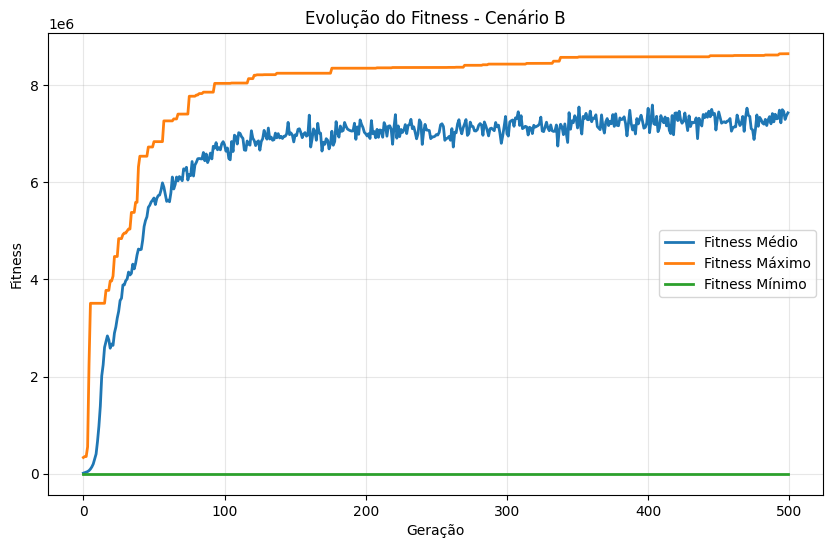

Gráfico salvo como 'fitness_evolution_scenario_b.png'


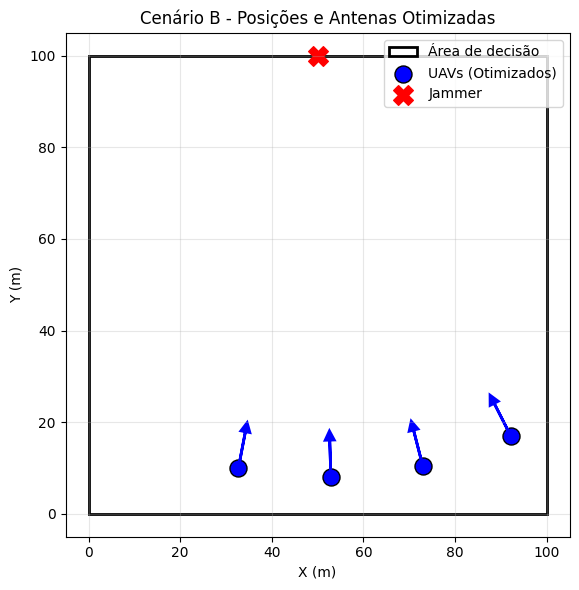

In [5]:
import random
import numpy as np
import math
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
from functools import partial
import networkx as nx
from link_capacity import calcular_capacidade_link, interference_from_jammer
from antenna_null import realistic_antenna_gain
import copy  # Adicionar no topo do arquivo com os outros imports

NUM_UAVS = 4
lambda_0 = 0.125
P_INTERFERENCE_DBM = 100
P_NOISE_DBM = -100
BANDWIDTH = 20e6
TRANSMIT_POWER_DBM = 20
MINDIST = 20

JAMMER_POSITION = np.array([50.0, 100.0])

# Definir os tipos de indivíduos e fitness
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# CENÁRIO B - Otimização de Posições

def create_individual_scenario_b(num_uavs, area_size=100):
    """
    Cria um indivíduo para o Cenário B com posições (x,y).
    Cada UAV tem: [x, y]
    """
    individual = []
    attempts = 0
    max_attempts = 1000
    
    while len(individual) < num_uavs * 2 and attempts < max_attempts:  # Mudou de *3 para *2
        x = random.uniform(0, area_size)
        y = random.uniform(0, area_size)
        
        # Verificar se a nova posição está longe o suficiente das anteriores
        valid_position = True
        current_positions = []
        for i in range(0, len(individual), 2):  # Mudou de 3 para 2
            current_positions.append([individual[i], individual[i+1]])
        
        for pos in current_positions:
            distance = np.linalg.norm(np.array([x, y]) - np.array(pos))
            if distance < MINDIST:
                valid_position = False
                break
        
        if valid_position:
            individual.extend([x, y])  # Só x,y (sem ângulo)
        
        attempts += 1
    
    # Se não conseguir gerar todas as posições válidas, aceitar assim mesmo
    while len(individual) < num_uavs * 2:  # Mudou de *3 para *2
        x = random.uniform(0, area_size)
        y = random.uniform(0, area_size)
        individual.extend([x, y])  # Só x,y
    
    return creator.Individual(individual)

def extract_positions_and_angles(individual, num_uavs):
    """
    Extrai posições e calcula ângulos dinamicamente baseados no jammer.
    Returns: (uav_positions, angles)
    """
    jammer_position = JAMMER_POSITION

    uav_positions = []
    angles = []
    
    for i in range(num_uavs):
        idx = i * 2  # Cada UAV tem 2 valores: x, y
        x = individual[idx]
        y = individual[idx + 1]
        
        # Calcular ângulo para apontar para o jammer
        dx = jammer_position[0] - x
        dy = jammer_position[1] - y
        angle = np.degrees(np.arctan2(dy, dx)) % 360  # Ângulo em graus
        
        uav_positions.append(np.array([x, y]))
        angles.append(angle)
    
    return uav_positions, angles

def plot_scenario_b(best_solution, jammer_position, num_uavs, filename="scenario_b.png"):
    """
    Plota o cenário B com posições e ângulos otimizados.
    """
    jammer_position = JAMMER_POSITION

    uav_positions, angles = extract_positions_and_angles(best_solution, num_uavs)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plotar área de decisão como quadrado preto
    square_size = 100
    square_x = 0
    square_y = 0
    square = plt.Rectangle((square_x, square_y), square_size, square_size, 
                          fill=False, edgecolor='black', linewidth=2, linestyle='-',
                          label='Área de decisão')
    ax.add_patch(square)
    
    # Plotar UAVs como círculos
    for i, pos in enumerate(uav_positions):
        if i == 0:
            ax.scatter(pos[0], pos[1], c='blue', s=150, marker='o', 
                      edgecolors='black', label='UAVs (Otimizados)')
        else:
            ax.scatter(pos[0], pos[1], c='blue', s=150, marker='o', edgecolors='black')
        
        # Seta indicando direção da antena
        angle_rad = np.radians(angles[i])
        arrow_length = 8
        end_x = pos[0] + arrow_length * np.cos(angle_rad)
        end_y = pos[1] + arrow_length * np.sin(angle_rad)
        
        ax.arrow(pos[0], pos[1], end_x - pos[0], end_y - pos[1],
                head_width=2, head_length=2, fc='blue', ec='blue', linewidth=2)
    
    # Plotar jammer como cruz vermelha
    ax.scatter(jammer_position[0], jammer_position[1], c='red', s=200, 
              marker='X', label='Jammer')
    
    # Configurar plot
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Cenário B - Posições e Antenas Otimizadas')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def print_communication_values_scenario_b(individual, num_uavs, jammer_position):
    """
    Calcula e imprime os valores de comunicação para o cenário B.
    """
    uav_positions, angles = extract_positions_and_angles(individual, num_uavs)
    alignments = [1.0] * num_uavs
    
    comm_matrix, interference_matrix = calculate_communication_capacity(
        angles, alignments, uav_positions, jammer_position
    )
    
    # Avaliar grafo
    G = nx.DiGraph()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j and comm_matrix[i][j] > 0:
                G.add_edge(i, j, capacity=comm_matrix[i][j])

    # Encontrar links usados através dos caminhos mínimos
    links_usados = set()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j:
                try:
                    path = nx.shortest_path(G, source=i, target=j, weight=lambda u, v, d: 1/d['capacity'])
                    for u, v in zip(path[:-1], path[1:]):
                        links_usados.add((u, v))
                        links_usados.add((v, u))
                except:
                    pass
    
    # Cálculo usando apenas links usados
    capacidades_usadas = [comm_matrix[u][v] for u, v in links_usados if u < num_uavs and v < num_uavs]
    if capacidades_usadas:
        C_media_total = np.mean(capacidades_usadas)
        C_min_total = min(capacidades_usadas)
    else:
        C_media_total = 0
        C_min_total = 0
    
    # Calcular fitness
    alpha, beta = 1.0, 1.0
    fitness = (C_media_total ** alpha) * (C_min_total ** beta)
    
    return capacidades_usadas, interference_matrix, C_media_total, C_min_total, fitness

# Função para calcular a capacidade de comunicação (mantém-se igual)
def calculate_communication_capacity(antenna_angles, alignments, positions, jammer_position):
    communication_capacity = np.zeros((NUM_UAVS, NUM_UAVS))
    interference_matrix = np.full((NUM_UAVS, NUM_UAVS), P_INTERFERENCE_DBM)

    for i in range(NUM_UAVS):
        null_dir_i = antenna_angles[i]

        dx_jam = jammer_position[0] - positions[i][0]
        dy_jam = jammer_position[1] - positions[i][1]
        dir_jammer_to_uav = np.degrees(np.arctan2(dy_jam, dx_jam)) % 360

        G_jammer_i = realistic_antenna_gain(dir_jammer_to_uav, null_dir_i)

        dist_jammer_i = np.linalg.norm(positions[i] - jammer_position)
        P_interf_dBm_i = interference_from_jammer(P_INTERFERENCE_DBM, G_jammer_i, lambda_0, dist_jammer_i)

        interference_matrix[i, :] = P_interf_dBm_i

    for i in range(NUM_UAVS):
        for j in range(NUM_UAVS):
            if i != j:
                null_dir_i = antenna_angles[i]
                null_dir_j = antenna_angles[j]

                dx_ij = positions[j][0] - positions[i][0]
                dy_ij = positions[j][1] - positions[i][1]
                dir_tx_to_rx = np.degrees(np.arctan2(dy_ij, dx_ij)) % 360

                dx_ji = positions[i][0] - positions[j][0]
                dy_ji = positions[i][1] - positions[j][1]
                dir_rx_to_tx = np.degrees(np.arctan2(dy_ji, dx_ji)) % 360

                G_tx = realistic_antenna_gain(dir_tx_to_rx, null_dir_i)
                G_rx = realistic_antenna_gain(dir_rx_to_tx, null_dir_j)

                capacity = calcular_capacidade_link(
                    pos1=positions[i],
                    pos2=positions[j],
                    lambda_0=lambda_0,
                    P_tx_dBm=TRANSMIT_POWER_DBM,
                    G_tx_dB=G_tx,
                    G_rx_dB=G_rx,
                    P_interference_dBm=interference_matrix[i, j],
                    P_noise_dBm=P_NOISE_DBM,
                    bandwidth=BANDWIDTH
                )

                communication_capacity[i][j] = capacity

    return communication_capacity, interference_matrix

def evaluate_individual_scenario_b(individual, num_uavs, jammer_position, min_distance=MINDIST):
    """
    Avalia um indivíduo no Cenário B (posições).
    """
    uav_positions, angles = extract_positions_and_angles(individual, num_uavs)
    
    # Verificar colisões entre UAVs
    for i in range(num_uavs):
        for j in range(i + 1, num_uavs):
            distance = np.linalg.norm(uav_positions[i] - uav_positions[j])
            if distance < min_distance:
                return (0.0,)  # Penalização por colisão
    
    # Calcular fitness usando a mesma lógica do Cenário A
    alignments = [1.0] * num_uavs
    comm_matrix, _ = calculate_communication_capacity(angles, alignments, uav_positions, jammer_position)

    # Avaliar grafo
    G = nx.DiGraph()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j and comm_matrix[i][j] > 0:
                G.add_edge(i, j, capacity=comm_matrix[i][j])

    # Encontrar links usados
    links_usados = set()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j:
                try:
                    path = nx.shortest_path(G, source=i, target=j, weight=lambda u, v, d: 1/d['capacity'])
                    for u, v in zip(path[:-1], path[1:]):
                        links_usados.add((u, v))
                        links_usados.add((v, u))
                except:
                    pass
    
    # Cálculo do fitness
    capacidades_usadas = [comm_matrix[u][v] for u, v in links_usados if u < num_uavs and v < num_uavs]
    if capacidades_usadas:
        C_media_total = np.mean(capacidades_usadas)
        C_min_total = min(capacidades_usadas)
    else:
        C_media_total = 0
        C_min_total = 0
    
    alpha, beta = 1.0, 1.0
    fitness = (C_media_total ** alpha) * (C_min_total ** beta)
    
    return (fitness,)

def mutate_individual_scenario_b(individual, mutation_rate, area_size=100):
    """
    Mutação para o Cenário B - muda posições.
    """
    num_uavs = len(individual) // 2  # Mudou de //3 para //2
    
    for i in range(num_uavs):
        idx = i * 2  # Mudou de *3 para *2
        if random.random() < mutation_rate:
            # Mutar posição X
            individual[idx] = random.uniform(0, area_size)
        if random.random() < mutation_rate:
            # Mutar posição Y  
            individual[idx + 1] = random.uniform(0, area_size)
    
    return individual,

def custom_crossover_scenario_b(ind1, ind2):
    """
    Crossover para o Cenário B - troca posições (x,y) entre indivíduos.
    """
    num_uavs = len(ind1) // 2  # Mudou de //3 para //2
    
    for i in range(num_uavs):
        if random.random() < 0.5:
            idx = i * 2  # Mudou de *3 para *2
            # Trocar posição do UAV (x, y)
            ind1[idx:idx+2], ind2[idx:idx+2] = ind2[idx:idx+2], ind1[idx:idx+2]  # Mudou de +3 para +2
    
    return ind1, ind2

def setup_deap_scenario_b(num_uavs, crossover_rate, mutation_rate, jammer_position, area_size=100):
    """
    Configuração do DEAP para o Cenário B.
    """
    toolbox = base.Toolbox()
    
    toolbox.register("individual", create_individual_scenario_b, num_uavs=num_uavs, area_size=area_size)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate_individual_scenario_b, 
                     num_uavs=num_uavs, 
                     jammer_position=jammer_position)
    toolbox.register("mate", custom_crossover_scenario_b)
    toolbox.register("mutate", mutate_individual_scenario_b, 
                     mutation_rate=mutation_rate, area_size=area_size)
    toolbox.register("select", tools.selTournament, tournsize=3)
    
    # ADICIONAR ESTA LINHA:
    toolbox.register("clone", copy.deepcopy)
    
    return toolbox

def genetic_algorithm_scenario_b(num_uavs, population_size, generations, crossover_rate, mutation_rate, jammer_position, area_size=100):
    """
    Algoritmo genético para o cenário B com elitismo.
    """
    # Configurar o DEAP
    toolbox = setup_deap_scenario_b(
        num_uavs=num_uavs,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        jammer_position=jammer_position,
        area_size=area_size
    )
    
    # Criar população inicial
    population = toolbox.population(n=population_size)
    
    # Avaliar a população inicial
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
    
    # Configurar estatísticas
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    # DEFINIR ELITISMO
    ELITISM_SIZE = max(1, population_size // 20)  # 5% da população ou pelo menos 1
    
    # Executar o algoritmo genético com elitismo
    for gen in range(generations):
        # 1. ELITISMO - Guardar os melhores
        elites = tools.selBest(population, k=ELITISM_SIZE)
        
        # 2. Criar nova população começando com os elites
        new_population = [toolbox.clone(elite) for elite in elites]
        
        # 3. Completar a população com crossover e mutação
        while len(new_population) < population_size:
            # SELEÇÃO POR TORNEIO
            parent1 = toolbox.select(population, 1)[0]
            parent2 = toolbox.select(population, 1)[0]
            
            # CROSSOVER
            if random.random() < crossover_rate:
                child1, child2 = toolbox.mate(toolbox.clone(parent1), toolbox.clone(parent2))
                
                # Limpar fitness dos filhos
                del child1.fitness.values
                del child2.fitness.values
                
                # MUTAÇÃO
                if random.random() < mutation_rate:
                    toolbox.mutate(child1)
                    del child1.fitness.values
                
                if random.random() < mutation_rate:
                    toolbox.mutate(child2)
                    del child2.fitness.values
                
                # Adicionar filhos à nova população
                if len(new_population) < population_size:
                    new_population.append(child1)
                if len(new_population) < population_size:
                    new_population.append(child2)
            else:
                # Se não há crossover, apenas muta um dos pais
                child = toolbox.clone(parent1)
                if random.random() < mutation_rate:
                    toolbox.mutate(child)
                    del child.fitness.values
                
                if len(new_population) < population_size:
                    new_population.append(child)
        
        # 4. Limitar o tamanho da população
        population = new_population[:population_size]
        
        # 5. Avaliar novos indivíduos (que não têm fitness válido)
        invalid_ind = [ind for ind in population if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
        
        # 6. Coletar estatísticas da geração atual
        record = stats.compile(population)
        
        # 7. Escrever os valores no arquivo
        write_fitness_values_scenario_b(gen, record["avg"], record["max"], record["min"], record["std"])
        
        # 8. Print de progresso (opcional)
        if gen % 50 == 0 or gen == generations - 1:
            print(f"Geração {gen}: Fitness Máximo = {record['max']:.6f}, Médio = {record['avg']:.6f}")
    
    # Retornar o melhor indivíduo
    best_individual = tools.selBest(population, k=1)[0]
    return best_individual

def write_fitness_values_scenario_b(gen, avg, max_val, min_val, std, filename="fitness_values_scenario_b.txt"):
    """
    Escreve os valores de fitness no arquivo para o cenário B.
    """
    with open(filename, "a") as file:
        if gen == 0:
            file.write("=== Cenário B ===\n")
            file.write("gen\tavg\tmax\tmin\tstd\n")
        file.write(f"{gen}\t{avg:.4f}\t{max_val:.4f}\t{min_val:.4f}\t{std:.4f}\n")

def save_best_solution_scenario_b(best_solution, jammer_position, filename="best_solution_scenario_b.txt"):
    """
    Salva a melhor solução para o cenário B.
    """
    uav_positions, angles = extract_positions_and_angles(best_solution, NUM_UAVS)
    
    with open(filename, "w") as file:
        file.write("=== Melhor Solução - Cenário B ===\n")
        file.write("Posições e Ângulos dos UAVs:\n")
        for i, (pos, angle) in enumerate(zip(uav_positions, angles)):
            file.write(f"UAV {i}: x={pos[0]:.2f}, y={pos[1]:.2f}, angle={angle:.2f}°\n")
        file.write(f"Posição do Jammer: x={jammer_position[0]:.2f}, y={jammer_position[1]:.2f}\n")

def plot_fitness_evolution_scenario_b(filename="fitness_values_scenario_b.txt"):
    """
    Plota a evolução do fitness ao longo das gerações para o cenário B.
    """
    try:
        generations = []
        avg_fitness = []
        max_fitness = []
        min_fitness = []
        
        with open(filename, "r") as file:
            lines = file.readlines()
            for line in lines:
                if line.startswith("gen\t"):
                    continue
                if "===" in line:
                    continue
                
                parts = line.strip().split("\t")
                if len(parts) == 5:
                    generations.append(int(parts[0]))
                    avg_fitness.append(float(parts[1]))
                    max_fitness.append(float(parts[2]))
                    min_fitness.append(float(parts[3]))
        
        if generations:
            plt.figure(figsize=(10, 6))
            plt.plot(generations, avg_fitness, label='Fitness Médio', linewidth=2)
            plt.plot(generations, max_fitness, label='Fitness Máximo', linewidth=2)
            plt.plot(generations, min_fitness, label='Fitness Mínimo', linewidth=2)
            plt.xlabel('Geração')
            plt.ylabel('Fitness')
            plt.title('Evolução do Fitness - Cenário B')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig('fitness_evolution_scenario_b.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("Gráfico salvo como 'fitness_evolution_scenario_b.png'")
    
    except Exception as e:
        print(f"Erro ao plotar gráfico: {e}")

# Função principal para o cenário B
def simulate_scenario_b(num_uavs=4, population_size=50, generations=50, crossover_rate=0.8, mutation_rate=0.15, jammer_position=None, area_size=100):
    """
    Simula o cenário B com otimização de posições e ângulos das antenas.
    """
    if jammer_position is None:
        jammer_position = np.array([50.0, 50.0])  # Jammer no centro da área
    
    print("=== Cenário B - Otimização de Posições + Ângulos ===")
    print(f"Área de decisão: {area_size}x{area_size} metros")
    print(f"Posição do Jammer: x={jammer_position[0]:.2f}, y={jammer_position[1]:.2f}")
    print()
    
    # Executar o algoritmo genético
    best_solution = genetic_algorithm_scenario_b(
        num_uavs=num_uavs,
        population_size=population_size,
        generations=generations,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        jammer_position=jammer_position,
        area_size=area_size
    )
    
    # Calcular e imprimir os resultados da melhor solução
    capacidades_usadas, interference_matrix, C_media_total, C_min_total, fitness = print_communication_values_scenario_b(
        best_solution, num_uavs, jammer_position
    )
    
    # Extrair posições e ângulos para imprimir
    uav_positions, angles = extract_positions_and_angles(best_solution, num_uavs)
    
    # Salvar a melhor solução
    save_best_solution_scenario_b(best_solution, jammer_position)
    
    # Imprimir resultados
    print("=== Resultados da Otimização ===")
    print("Posições e ângulos ótimos dos UAVs:")
    for i, (pos, angle) in enumerate(zip(uav_positions, angles)):
        print(f"  UAV {i}: x={pos[0]:.2f}, y={pos[1]:.2f}, angle={angle:.2f}°")
    print()
    print(f"Fitness final: {fitness:.4f}")
    print(f"Capacidade média dos links usados: {C_media_total:.2f} bps")
    print(f"Capacidade mínima dos links usados: {C_min_total:.2f} bps")
    print(f"Número de links usados: {len(capacidades_usadas)}")
    
    # Plotar gráficos
    plot_fitness_evolution_scenario_b(filename="fitness_values_scenario_b.txt")
    
    
    # Plotar cenários
    plot_scenario_b(best_solution, jammer_position, num_uavs)

    
    return best_solution, jammer_position, capacidades_usadas, interference_matrix

# Exemplo de uso
if __name__ == "__main__":
    # Limpar arquivos anteriores
    open("fitness_values_scenario_b.txt", "w").close()
    
    # Posição do jammer
    jammer_position = JAMMER_POSITION
    
    # Executar simulação
    best_solution, jammer_pos, capacidades, interference = simulate_scenario_b(
        num_uavs=4,
        population_size=500,
        generations=500,
        crossover_rate=0.8,
        mutation_rate=0.2,
        jammer_position=jammer_position,
        area_size=100
    )
    